# Test `GaussianChargeSharingKb` Python bindings

This notebook tests and benchmarks the Aare Minuit2 object API for the 8-parameter Kα/Kβ charge-sharing model.

\[
f(x)=p_0-p_1x+N\left[
G_\alpha(x)+qG_\beta(x)+C H_\alpha(x)+qC H_\beta(x)
\right]
\]

with

\[
\mu_\beta = r\mu_\alpha
\]

Parameter order:

```text
[p0, p1, mu, sigma, N, C, kb_mean, kb_frac]
```

where:

```text
kb_mean = r
kb_frac = q
```

In [1]:
import time
import numpy as np
np.set_printoptions(suppress=True, precision=6)

import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.optimize import curve_fit
from pprint import pprint

import sys
sys.path.insert(0, "/home/ferjao_k/sw/aare/build")

from aare import GaussianChargeSharingKb

In [2]:
def gaussian_charge_sharing_kb(x, p):
    p0, p1, mu, sigma, N, C, kb_mean, kb_frac = p

    mu_b = kb_mean * mu

    u = (x - mu) / sigma
    ub = (x - mu_b) / sigma

    G = np.exp(-0.5 * u**2)
    Gb = np.exp(-0.5 * ub**2)

    H = 0.5 * (1.0 - erf(u / np.sqrt(2.0)))
    Hb = 0.5 * (1.0 - erf(ub / np.sqrt(2.0)))

    return p0 - p1 * x + N * (G + kb_frac * Gb + C * H + kb_frac * C * Hb)

def gaussian_charge_sharing_kb_curve_fit(x, p0, p1, mu, sigma, N, C, kb_mean, kb_frac):
    return gaussian_charge_sharing_kb(
        x,
        np.array([p0, p1, mu, sigma, N, C, kb_mean, kb_frac], dtype=float),
    )

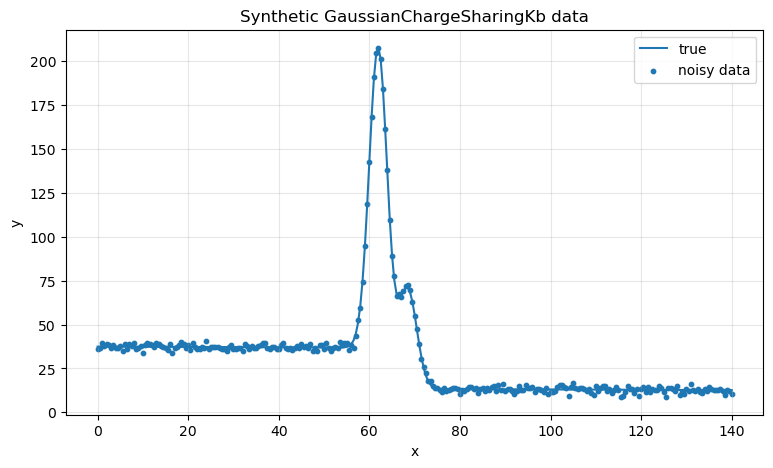

In [13]:
rng = np.random.default_rng(123)

x = np.linspace(0.0, 140.0, 281)

p_true = np.array([
    14.0,   # p0
    0.010,  # p1, model uses p0 - p1*x
    62.0,   # mu: K-alpha position
    2.0,    # sigma
    180.0,  # N
    0.10,   # C: charge-sharing plateau
    1.105,  # kb_mean: K-beta mean ratio
    0.3,   # kb_frac: K-beta fraction
])

noise_sigma = 1.5
y_true = gaussian_charge_sharing_kb(x, p_true)
y = y_true + rng.normal(0.0, noise_sigma, size=x.shape)
y_err = np.full_like(x, noise_sigma)

plt.figure(figsize=(9, 5))
plt.plot(x, y_true, label="true")
plt.scatter(x, y, s=10, label="noisy data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic GaussianChargeSharingKb data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# SciPy reference fit
p0_ref = np.array([12.0, 0.0, 60.0, 6.0, 150.0, 0.20, 1.10, 0.10])

bounds_ref = (
    [-np.inf, -np.inf, 0.0, 1e-12, 0.0, -np.inf, 1.02, 0.0],
    [ np.inf,  np.inf, 140.0, 50.0, np.inf,  np.inf, 1.40, 1.00],
)

p_scipy, cov_scipy = curve_fit(
    gaussian_charge_sharing_kb_curve_fit,
    x,
    y,
    p0=p0_ref,
    sigma=y_err,
    absolute_sigma=True,
    bounds=bounds_ref,
    maxfev=50_000,
)

print("True params     :", p_true)
print("SciPy params    :", p_scipy)
print("SciPy abs error :", np.abs(p_scipy - p_true))

True params     : [ 14.      0.01   62.      2.    180.      0.1     1.105   0.3  ]
SciPy params    : [ 14.534234   0.015155  62.003314   1.998024 180.396284   0.098433
   1.104748   0.302732]
SciPy abs error : [0.534234 0.005155 0.003314 0.001976 0.396284 0.001567 0.000252 0.002732]


In [5]:
# Aare / Minuit2 object API fit
model = GaussianChargeSharingKb()

print("Parameter list:")
print(model.par_names)
print("n_par:", model.n_par)
print()

model.SetParameter("p0", 12.0)
model.SetParameter("p1", 0.0)
model.SetParameter("mu", 58.0)
model.SetParameter("sigma", 4.0)
model.SetParameter("N", 150.0)
model.SetParameter("C", 0.10)
model.SetParameter("kb_mean", 1.20)
model.SetParameter("kb_frac", 0.40)

model.SetParLimits("kb_mean", 1.02, 1.40)
model.SetParLimits("kb_frac", 0.0, 1.00)

model.compute_errors = True
model.max_calls = 4000
model.tolerance = 0.01

res_aare = model.fit(x, y, y_err)
pprint(res_aare, sort_dicts=False)

p_aare = np.array(res_aare["par"], dtype=float)

print()
print("True params     :", p_true)
print("SciPy params    :", p_scipy)
print("Aare params     :", p_aare)
print("SciPy abs error :", np.abs(p_scipy - p_true))
print("Aare abs error  :", np.abs(p_aare - p_true))
print("Aare - SciPy    :", p_aare - p_scipy)

Parameter list:
['p0', 'p1', 'mu', 'sigma', 'N', 'C', 'kb_mean', 'kb_frac']
n_par: 8

{'par': array([ 14.534164,   0.015155,  62.003317,   1.99802 , 180.396621,
         0.098433,   1.104748,   0.302733]),
 'par_err': array([0.564971, 0.005172, 0.009856, 0.008685, 0.698493, 0.00188 ,
       0.000509, 0.003632]),
 'chi2': array([262.404385])}

True params     : [ 14.      0.01   62.      2.    180.      0.1     1.105   0.3  ]
SciPy params    : [ 14.534234   0.015155  62.003314   1.998024 180.396284   0.098433
   1.104748   0.302732]
Aare params     : [ 14.534164   0.015155  62.003317   1.99802  180.396621   0.098433
   1.104748   0.302733]
SciPy abs error : [0.534234 0.005155 0.003314 0.001976 0.396284 0.001567 0.000252 0.002732]
Aare abs error  : [0.534164 0.005155 0.003317 0.00198  0.396621 0.001567 0.000252 0.002733]
Aare - SciPy    : [-0.00007  -0.        0.000003 -0.000004  0.000337 -0.       -0.
  0.000001]


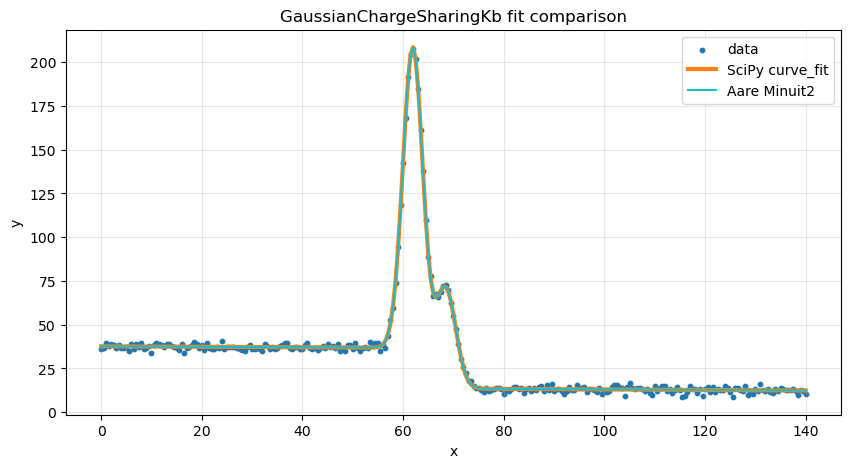

In [12]:
plt.figure(figsize=(10, 5))
# plt.plot(x, y_true, label="true")
plt.scatter(x, y, s=10, label="data")
plt.plot(x, gaussian_charge_sharing_kb(x, p_scipy), linewidth=3.0, label="SciPy curve_fit", color="tab:orange")
plt.plot(x, model(x, p_aare), linewidth=1.5, label="Aare Minuit2", color="tab:cyan")
plt.xlabel("x")
plt.ylabel("y")
plt.title("GaussianChargeSharingKb fit comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
def bench(fn, n_repeats=200):
    for _ in range(3):
        fn()

    t0 = time.perf_counter()
    for _ in range(n_repeats):
        res = fn()
    t1 = time.perf_counter()

    return res, (t1 - t0) / n_repeats

def fit_scipy_once():
    return curve_fit(
        gaussian_charge_sharing_kb_curve_fit,
        x,
        y,
        p0=p0_ref,
        sigma=y_err,
        absolute_sigma=True,
        bounds=bounds_ref,
        maxfev=50_000,
    )[0]

def fit_aare_once():
    m = GaussianChargeSharingKb()
    m.SetParameter("p0", 10.0)
    m.SetParameter("p1", 0.0)
    m.SetParameter("mu", 50.0)
    m.SetParameter("sigma", 5.0)
    m.SetParameter("N", 150.0)
    m.SetParameter("C", 0.10)
    m.SetParameter("kb_mean", 1.20)
    m.SetParameter("kb_frac", 0.40)
    
    m.SetParLimits("kb_mean", 1.02, 1.40)
    m.SetParLimits("kb_frac", 0.0, 1.00)
    m.max_calls = 4000
    m.tolerance = 0.01
    return np.array(m.fit(x, y, y_err)["par"], dtype=float)

p_scipy_bench, t_scipy = bench(fit_scipy_once, n_repeats=200)
p_aare_bench, t_aare = bench(fit_aare_once, n_repeats=200)

print(f"SciPy curve_fit : {1e3*t_scipy:.3f} ms")
print(f"Aare Minuit2    : {1e3*t_aare:.3f} ms")
print()
print("SciPy bench params:", p_scipy_bench)
print("Aare bench params :", p_aare_bench)

SciPy curve_fit : 17.591 ms
Aare Minuit2    : 1.888 ms

SciPy bench params: [ 14.534234   0.015155  62.003314   1.998024 180.396284   0.098433
   1.104748   0.302732]
Aare bench params : [ 32.421516   0.162626  62.154113   2.413067 169.643047   0.05319
   1.271962   0.      ]


## No-Kβ sanity check

For no-Kβ data, prefer `GaussianChargeSharing`.

You can also use this 8-parameter model and fix:

```python
model.FixParameter("kb_frac", 0.0)
```

but the 6-parameter model is cleaner and usually better conditioned.